# KO Case 03: GLI Directional DEG Enrichment 

This notebook summarizes directional enrichment analysis for GLI-family compensation.

Biological objective:
1. Load DEG enrichment outputs generated from directional grouping analyses.
2. Focus on the `Gli1/Gli3 combined` directional category across lineages.
3. Materialize an interpretable barplot of same-direction enrichment strength.

Import required packages.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Set paths and verify directional enrichment summary assets.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


repo_root = find_repo_root(Path.cwd().resolve())
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'knockout_section'
data_root = repo_root / 'data' / 'knockout'

case_output_root = tutorials_root / 'outputs' / 'knockout_gli_deg_enrichment_summary'
TABLE_DIR = case_output_root / '01_tables'
FIG_DIR = case_output_root / '02_figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CATEGORY_TABLES = {
    'gli1': tutorials_root / 'resources' / 'knockout' / 'gene_compensation_clean_github' / 'gli' / 'output' / 'deg_enrichment_gli1.csv',
    'gli3': tutorials_root / 'resources' / 'knockout' / 'gene_compensation_clean_github' / 'gli' / 'output' / 'deg_enrichment_gli3.csv',
    'gli1_gli3': tutorials_root / 'resources' / 'knockout' / 'gene_compensation_clean_github' / 'gli' / 'output' / 'deg_enrichment_gli1_gli3.csv',
    'gli1_gli3_combined': tutorials_root / 'resources' / 'knockout' / 'gene_compensation_clean_github' / 'gli' / 'output' / 'deg_enrichment_gli1_gli3_combined.csv',
}

missing = [f'{k}: {v}' for k, v in CATEGORY_TABLES.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required files\n' + '\n'.join(missing))

print('Repository root :', repo_root)
print('Tutorial root   :', tutorials_root.relative_to(repo_root))
print('Case output root:', case_output_root.relative_to(repo_root))


Repository root : /workspace/fuchenghao/Navigo_unified_repo
Tutorial root   : docs/tutorials
Case output root: docs/tutorials/outputs/knockout_gli_deg_enrichment_summary


## Step 1: Summarize directional DEG enrichment categories
Build an overview table across GLI directional categories for quick QC and interpretation.

In [3]:
rows = []
for category, path in CATEGORY_TABLES.items():
    df = pd.read_csv(path)
    rows.append({
        'category': category,
        'num_rows': int(len(df)),
        'min_same_p': float(df['same_p_value'].min()),
        'min_opposite_p': float(df['opposite_p_value'].min()),
        'path': str(path.relative_to(repo_root)),
    })

overview = pd.DataFrame(rows).sort_values('category').reset_index(drop=True)
overview_out = TABLE_DIR / '01_deg_enrichment_category_overview.csv'
overview.to_csv(overview_out, index=False)
print('Saved:', overview_out.relative_to(repo_root))
overview

Saved: docs/tutorials/outputs/knockout_gli_deg_enrichment_summary/01_tables/01_deg_enrichment_category_overview.csv


,category,num_rows,min_same_p,min_opposite_p,path
0,gli1,6,3.872642e-06,0.941806,docs/tutorials/resources/knockout/gene_compens...
1,gli1_gli3,6,1.871123e-06,0.701700,docs/tutorials/resources/knockout/gene_compens...
2,gli1_gli3_combined,6,1.254366e-05,0.975739,docs/tutorials/resources/knockout/gene_compens...
3,gli3,6,3.447199e-07,0.008636,docs/tutorials/resources/knockout/gene_compens...


## Step 2: Build plot-ready table for `Gli1/Gli3 combined` directional enrichment

In [4]:
plot_order = [
    'Limb_mesenchyme_trajectory',
    'Chondrocyte_trajectory',
    'Intermediate_mesoderm_trajectory',
    'Motor_neuron_trajectory',
    'Spinal_cord_dorsal_trajectory',
    'Osteoblast_trajectory',
]
plot_labels = [
    'Limb mesenchyme',
    'Chondrocyte',
    'Intermediate mesoderm',
    'Motor neuron',
    'Spinal cord dorsal',
    'Osteoblast',
]

df = pd.read_csv(CATEGORY_TABLES['gli1_gli3_combined']).set_index('cell_type').loc[plot_order].reset_index()
df['label'] = plot_labels
df['same_neglog10p'] = -np.log10(df['same_p_value'].clip(lower=1e-300))
df['different_neglog10p'] = -np.log10(df['opposite_p_value'].clip(lower=1e-300))

plot_table = df[['cell_type', 'label', 'same_p_value', 'opposite_p_value', 'same_neglog10p', 'different_neglog10p']]
plot_table_out = TABLE_DIR / '01_gli1_gli3_combined_plot_table.csv'
plot_table.to_csv(plot_table_out, index=False)
print('Saved:', plot_table_out.relative_to(repo_root))
plot_table

Saved: docs/tutorials/outputs/knockout_gli_deg_enrichment_summary/01_tables/01_gli1_gli3_combined_plot_table.csv


,cell_type,label,same_p_value,opposite_p_value,same_neglog10p,different_neglog10p
0,Limb_mesenchyme_trajectory,Limb mesenchyme,0.021974,0.983518,1.658081,0.007218
1,Chondrocyte_trajectory,Chondrocyte,0.038807,0.975739,1.411091,0.010666
2,Intermediate_mesoderm_trajectory,Intermediate mesoderm,0.031062,0.977363,1.507769,0.009944
3,Motor_neuron_trajectory,Motor neuron,0.000018,0.999991,4.738028,0.000004
4,Spinal_cord_dorsal_trajectory,Spinal cord dorsal,0.000013,0.999996,4.901576,0.000002
5,Osteoblast_trajectory,Osteoblast,0.001739,0.999179,2.759713,0.000357


## Step 3: Materialize same-direction DEG enrichment barplot
Display lineage-wise enrichment strength for the directional compensation category.

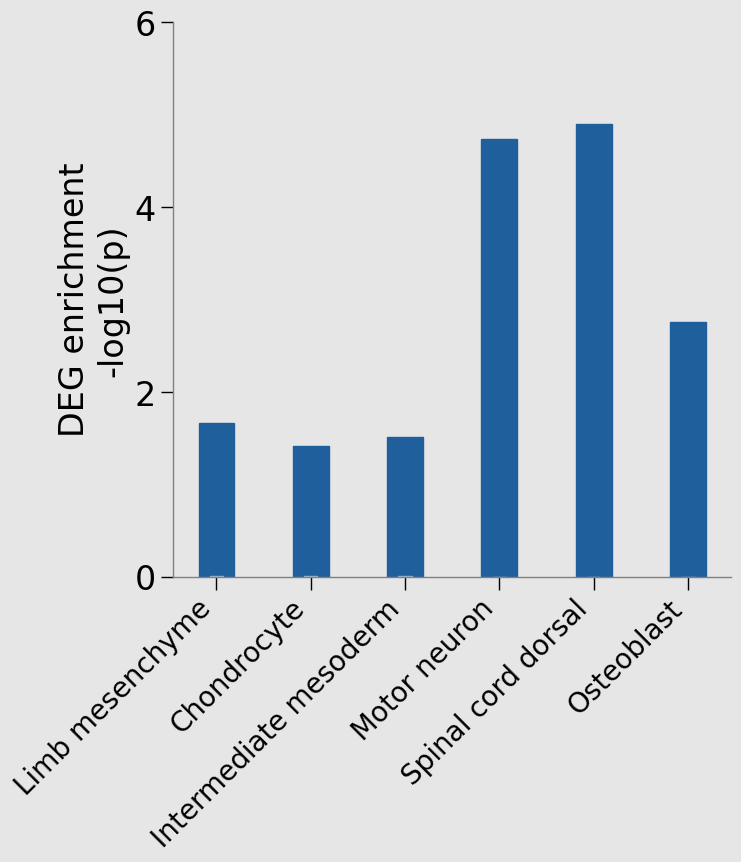

Saved figure: docs/tutorials/outputs/knockout_gli_deg_enrichment_summary/02_figures/01_gli1_gli3_combined_deg_enrichment_barplot.png


In [5]:
x = np.arange(len(plot_table))
same_vals = plot_table['same_neglog10p'].to_numpy()
diff_vals = plot_table['different_neglog10p'].to_numpy()

fig, ax = plt.subplots(figsize=(7.2, 7.2), facecolor='#e6e6e6')
ax.set_facecolor('#e6e6e6')

ax.bar(x, same_vals, width=0.38, color='#1f5f9c', edgecolor='#1f5f9c')
ax.bar(x, diff_vals, width=0.14, color='#9eb7da', edgecolor='#9eb7da')

ax.set_xticks(x)
ax.set_xticklabels(plot_table['label'], rotation=45, ha='right', fontsize=20)
ax.set_ylabel('DEG enrichment\n-log10(p)', fontsize=24)
ax.set_ylim(0, 6.0)
ax.set_yticks([0, 2, 4, 6])
ax.tick_params(axis='y', labelsize=24, width=1.0, length=9)
ax.tick_params(axis='x', width=1.0, length=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['left'].set_color('#808080')
ax.spines['bottom'].set_color('#808080')

fig_out = FIG_DIR / '01_gli1_gli3_combined_deg_enrichment_barplot.png'
fig.savefig(fig_out, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved figure:', fig_out.relative_to(repo_root))

## Biological interpretation guide for directional compensation
- **Directional grouping concept**: genes are separated by whether `Gli2` regulation direction is concordant or discordant with `Gli1/Gli3`-related perturbation responses.
- **Enrichment pattern**: same-direction groups show stronger enrichment of experimental `Gli2` KO DEGs across key lineages, supporting biologically meaningful directional consistency.
- **Compensation readout**: stronger same-direction enrichment is compatible with the idea that relative paralog activity shapes KO vulnerability in a lineage-dependent way.
- **Biological takeaway**: directional concordance metrics can prioritize genes/pathways most likely to mediate compensatory buffering versus sensitivity.